# Plotting t dep checkpoint

In [2]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "/gpfs/home/jd925/Adding_stellar_masses")
import jax
jax.config.update("jax_enable_x64", True)
import sys
sys.path.append("/gpfs/home/jd925/Adding_stellar_masses")
import jaxsp as jsp

m22=50, r0=0.19, Lout=0.2 (checkpoints: /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/checkpoints_m22_50_r0_0.19_Lout_0.2)

Loading /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/checkpoints_m22_50_r0_0.19_Lout_0.2/checkpoint_final.pkl


Steps: 2446, ramp steps: 0, dt = 0.00409 Gyr
Particles: 100, time points: 2447
Inferred r_half = 0.1882 kpc
T_orb = 0.102 Gyr, T_c = 0.003 Gyr


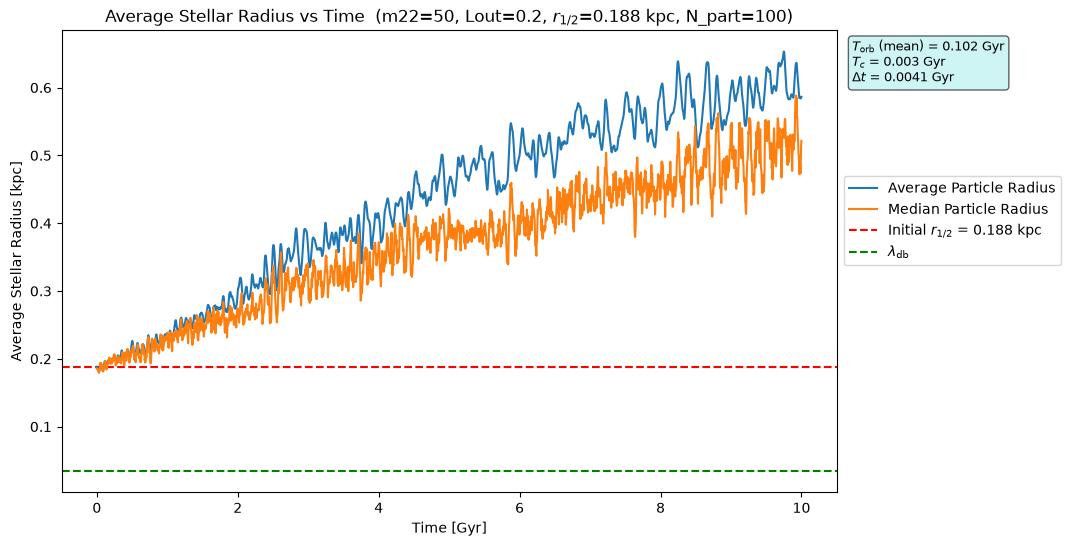

In [38]:
m22 = 50
r0 = 0.19
Lout = 0.2
rcut = None


WORKDIR = "/gpfs/home/jd925/Adding_stellar_masses/Checkpoints"

m22_str = f"{m22:g}"
r0_str = f"{r0:g}"
Lout_str = f"{Lout:g}"

if rcut is None:
    Ckpt_dir = os.path.join(WORKDIR, f"checkpoints_m22_{m22_str}_r0_{r0_str}_Lout_{Lout_str}")
else:
    Ckpt_dir = os.path.join(WORKDIR, f"checkpoints_rcut{rcut}_m22_{m22_str}_r0_{r0_str}_Lout_{Lout_str}")

Plot_dir = "/gpfs/home/jd925/Adding_stellar_masses/Plots/T_dep" + "/M_" + m22_str + "/"

os.makedirs(Plot_dir, exist_ok=True)

u = jsp.set_schroedinger_units(m22)

to_Kpc = float(u.to_Kpc)
to_kms = float(u.to_kms)
to_Gyr = float(u.to_Gyr)

print(f"m22={m22}, r0={r0}, Lout={Lout} (checkpoints: {Ckpt_dir})")

# Load final checkpoint
ckpt_path = os.path.join(Ckpt_dir, "checkpoint_final.pkl")

print(f"\nLoading {ckpt_path}")

with open(ckpt_path, "rb") as f:
    state = pickle.load(f)

n_steps = state["no_time_steps"]
n_ramp  = state.get("n_ramp_steps", 0)
dt_Gyr  = (state["sim_time"] / n_steps) * to_Gyr
#dt_Gyr  = (state["sim_t"] / n_steps) * to_Gyr
print(f"Steps: {n_steps}, ramp steps: {n_ramp}, dt = {dt_Gyr:.5f} Gyr")

particles = state["particle_states"]

r_all  = np.array([p["r_values"] for p in particles])                              # (N_part, N_steps+1)
v_cart = np.array([[np.asarray(v) for v in p["velocities_cart"]] for p in particles])  # (N_part, N_steps+1, 3)
ke_all = np.array([p["kinetic_energy"]   for p in particles])                       # (N_part, N_steps+1)
pe_all = np.array([p["potential_energy"] for p in particles])                       # (N_part, N_steps+1)
am_all = np.array([p["ang_mom"]          for p in particles])                       # (N_part, N_steps+1[, 3])

N_part, N_t = r_all.shape
print(f"Particles: {N_part}, time points: {N_t}")

# Infer r_half from initial particle radii
r_half_kpc  = float(np.mean(r_all[:, 0])) * to_Kpc
r_half_str  = f"{r_half_kpc:.2f}"
print(f"Inferred r_half = {r_half_kpc:.4f} kpc")

avg_r = np.mean(r_all, axis=0)         # (N_steps+1,)
x     = np.arange(N_t) * dt_Gyr       # time axis in Gyr

# Timescale diagnostics from initial conditions (consistent with Running_sims.py)
v0 = np.sqrt(2 * ke_all[:, 0])                        # (N_part,) initial speeds, code units
mean_T_orb    = float(np.mean(2 * np.pi * r_all[:, 0] / v0)) * to_Gyr
lambda_db_kpc = 19.15 / (m22 * v0 * to_kms)           # de Broglie wavelength, kpc
T_c           = float(np.mean(lambda_db_kpc / (v0 * to_Kpc))) * to_Gyr

print(f"T_orb = {mean_T_orb:.3f} Gyr, T_c = {T_c:.3f} Gyr")


# --- Plot 1: Average stellar radius vs time ---
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x, avg_r * to_Kpc, label="Average Particle Radius", zorder=3)
ax.plot(x, np.median(r_all, axis=0) * to_Kpc, label="Median Particle Radius", zorder=3)

#for i in range(N_part):
#    ax.plot(x, r_all[i] * to_Kpc, alpha=0.2, color="gray")

ax.axhline(r_half_kpc, color="r", linestyle="--",
           label=f"Initial $r_{{1/2}}$ = {r_half_kpc:.3f} kpc")

ax.axhline(float(np.mean(lambda_db_kpc)), color="g", linestyle="--",
           label=r"$\lambda_{\rm db}$")

info = (
    f"$T_{{\\rm orb}}$ (mean) = {mean_T_orb:.3f} Gyr\n"
    f"$T_c$ = {T_c:.3f} Gyr\n"
    f"$\\Delta t$ = {dt_Gyr:.4f} Gyr"
)
ax.text(1.02, 0.98, info, transform=ax.transAxes,
        verticalalignment="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="paleturquoise", alpha=0.6))

ax.set_xlabel("Time [Gyr]")
#ax.set_yscale("log")
ax.set_ylabel("Average Stellar Radius [kpc]")
ax.set_title(f"Average Stellar Radius vs Time  (m22={m22}, Lout={Lout}, $r_{{1/2}}$={r_half_kpc:.3f} kpc, N_part={N_part})")
ax.legend(bbox_to_anchor=(1, 0.7))
plt.show()




In [6]:

out1 = os.path.join(Plot_dir, f"t_dep_lf_m{m22_str}_R0_{r_half_str}_Lout{Lout_str}_part_{N_part}_rcut{rcut}.png")
fig.savefig(out1, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"\nSaved: {out1}")


Saved: /gpfs/home/jd925/Adding_stellar_masses/Plots/T_dep/M_10/t_dep_lf_m10_R0_1.00_Lout1_part_100_rcut10.png


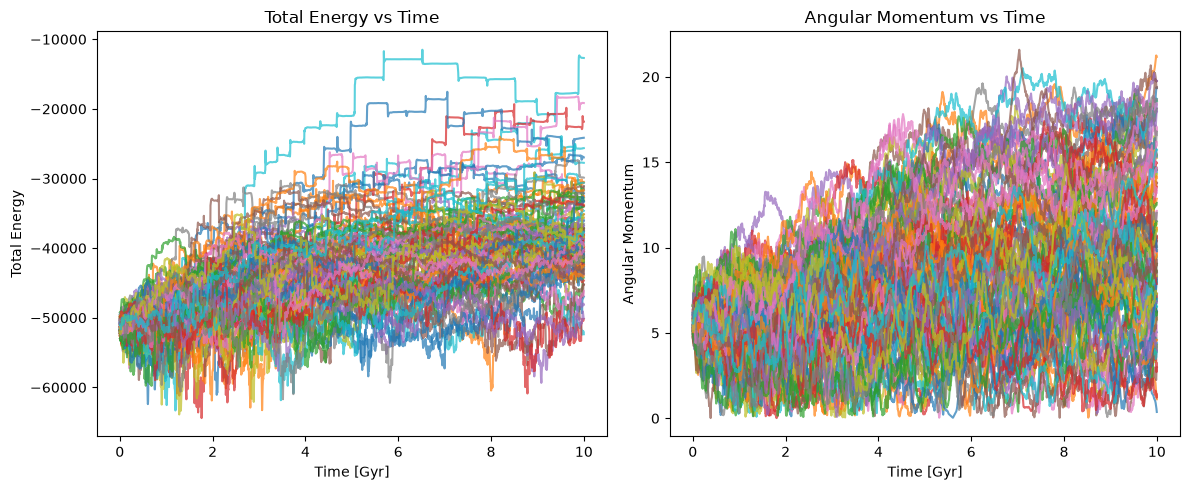

In [39]:
# --- Plot 2: Energy and angular momentum ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i in range(N_part):
    axes[0].plot(x, ke_all[i] + pe_all[i], alpha=0.7, label=f"Particle {i}")
axes[0].set_xlabel("Time [Gyr]")
axes[0].set_ylabel("Total Energy")
axes[0].set_title("Total Energy vs Time")

for i in range(N_part):
    axes[1].plot(x, am_all[i], alpha=0.7)
axes[1].set_xlabel("Time [Gyr]")
axes[1].set_ylabel("Angular Momentum")
axes[1].set_title("Angular Momentum vs Time")

plt.tight_layout()
plt.show()

In [8]:
out2 = os.path.join(Plot_dir, f"t_dep_lf_eng_amom_m{m22_str}_R0_{r_half_str}_Lout{Lout_str}_part_{N_part}_rcut{rcut}.png")
fig.savefig(out2, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"Saved: {out2}")

Saved: /gpfs/home/jd925/Adding_stellar_masses/Plots/T_dep/M_10/t_dep_lf_eng_amom_m10_R0_1.00_Lout1_part_100_rcut10.png


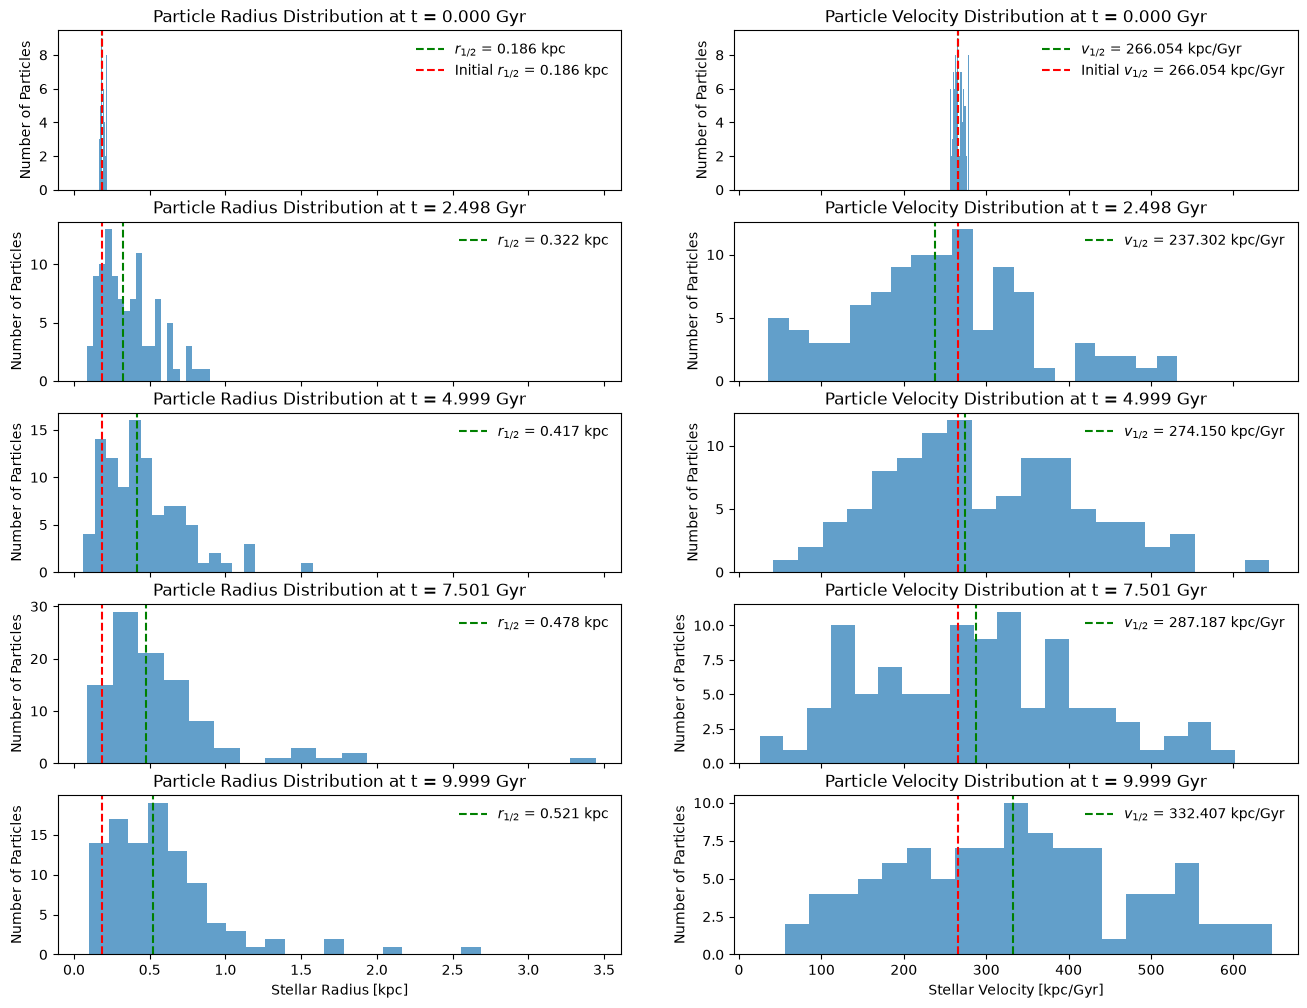

In [42]:
fig, ax = plt.subplots(5, 2, figsize=(16, 12), sharex='col')

v_cart_mag = np.linalg.norm(v_cart, axis=2)  # (N_part, N_steps+1)

timestamps = [0, int(N_t/4), int(N_t/2), int(3*N_t/4), N_t-1]

for i in range(len(timestamps)):

    t = timestamps[i]
    ax[i, 0].hist(r_all[:, t] * to_Kpc, bins=20, alpha=0.7)

    ax[i, 0].set_title(f"Particle Radius Distribution at t = {t*dt_Gyr:.3f} Gyr")

    ax[i, 0].set_ylabel("Number of Particles")

    if i == len(timestamps) - 1:
        ax[i, 0].set_xlabel("Stellar Radius [kpc]")

    ax[i, 0].axvline(np.median(r_all[:, t] * to_Kpc), color="g", linestyle="--", label=f"$r_{{1/2}}$ = {np.median(r_all[:, t] * to_Kpc):.3f} kpc")

    if i == 0:
        ax[i, 0].axvline(np.median(r_all[:, 0] * to_Kpc), color="r", linestyle="--", label=f"Initial $r_{{1/2}}$ = {np.median(r_all[:, 0] * to_Kpc):.3f} kpc")

    else:
        ax[i, 0].axvline(np.median(r_all[:, 0] * to_Kpc), color="r", linestyle="--")

    ax[i, 0].legend(fontsize = 10, frameon = False)


    ax[i, 1].hist(v_cart_mag[:, t] * to_Kpc, bins=20, alpha=0.7)

    ax[i, 1].set_title(f"Particle Velocity Distribution at t = {t*dt_Gyr:.3f} Gyr")

    ax[i, 1].set_ylabel("Number of Particles")

    if i == len(timestamps) - 1:
        ax[i, 1].set_xlabel("Stellar Velocity [kpc/Gyr]")

    ax[i, 1].axvline(np.median(v_cart_mag[:, t] * to_Kpc), color="g", linestyle="--", label=f"$v_{{1/2}}$ = {np.median(v_cart_mag[:, t] * to_Kpc):.3f} kpc/Gyr")


    if i == 0:
        ax[i, 1].axvline(np.median(v_cart_mag[:, 0] * to_Kpc), color="r", linestyle="--", label=f"Initial $v_{{1/2}}$ = {np.median(v_cart_mag[:, 0] * to_Kpc):.3f} kpc/Gyr")

    else:
        ax[i, 1].axvline(np.median(v_cart_mag[:, 0] * to_Kpc), color="r", linestyle="--")

    ax[i, 1].legend(fontsize = 10, frameon = False)

plt.show()



# Compare multiple runs

m22=10, r0=0.19, Lout=1.0 (checkpoints: /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/L_reduc/checkpointsm22_10_r0_0.19_Lout_1)

Loading /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/L_reduc/checkpointsm22_10_r0_0.19_Lout_1/checkpoint_final.pkl
Steps: 1295, ramp steps: 0, dt = 0.00772 Gyr
Particles: 1000, time points: 1296
Inferred r_half = 0.0779 kpc
m22=10, r0=0.19, Lout=0.8 (checkpoints: /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/L_reduc/checkpointsm22_10_r0_0.19_Lout_0.8)

Loading /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/L_reduc/checkpointsm22_10_r0_0.19_Lout_0.8/checkpoint_final.pkl
Steps: 1295, ramp steps: 0, dt = 0.00772 Gyr
Particles: 1000, time points: 1296
Inferred r_half = 0.0779 kpc
m22=10, r0=0.19, Lout=0.6 (checkpoints: /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/L_reduc/checkpointsm22_10_r0_0.19_Lout_0.6)

Loading /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/L_reduc/checkpointsm22_10_r0_0.19_Lout_0.6/checkpoint_final.pkl
Steps: 12

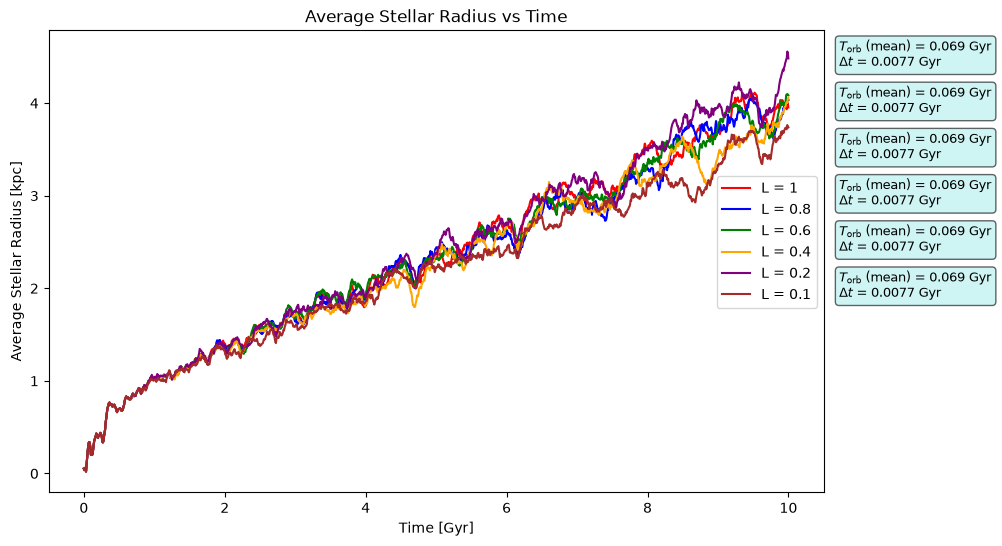

In [3]:

WORKDIR = "/gpfs/home/jd925/Adding_stellar_masses/Checkpoints/L_reduc"

#Ckpt_dirs = ["checkpointsm22_10_r0_0.19_Lout_1_run_0", "checkpointsm22_10_r0_0.19_Lout_1_run_1"]

#Ckpt_dirs = ["checkpoints_rcut10_m22_10_r0_0.19_Lout_1", "checkpointsm22_10_r0_0.19_Lout_1"]

Ckpt_dirs = ["checkpointsm22_10_r0_0.19_Lout_1", "checkpointsm22_10_r0_0.19_Lout_0.8", "checkpointsm22_10_r0_0.19_Lout_0.6", 
             "checkpointsm22_10_r0_0.19_Lout_0.4", "checkpointsm22_10_r0_0.19_Lout_0.2", "checkpointsm22_10_r0_0.19_Lout_0.1"] 
             #"checkpointsm22_10_r0_0.19_Lout_0.05", "checkpointsm22_10_r0_0.19_Lout_0.025", "checkpointsm22_10_r0_0.19_Lout_0.01"]

colours = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

#labels = ['Run 1', 'Run 2']

#labels = ['with rcut=10', 'without rcut']

labels = ['L = 1', 'L = 0.8', 'L = 0.6', 'L = 0.4', 'L = 0.2', 'L = 0.1', 'L = 0.05', 'L = 0.025', 'L = 0.01']

for i in range (len(Ckpt_dirs)):
    Ckpt_dir = os.path.join(WORKDIR, Ckpt_dirs[i])

    m22 = int(Ckpt_dirs[i].split("22_")[1].split("_")[0])  # Extract m22 from the directory name
    r0 = float(Ckpt_dirs[i].split("r0_")[1].split("_")[0])  # Extract r0 from the directory name
    Lout = float(Ckpt_dirs[i].split("Lout_")[1].split("_")[0])  # Extract Lout from the directory name

    u = jsp.set_schroedinger_units(m22)

    to_Kpc = float(u.to_Kpc)
    to_kms = float(u.to_kms)
    to_Gyr = float(u.to_Gyr)


    print(f"m22={m22}, r0={r0}, Lout={Lout} (checkpoints: {Ckpt_dir})")

    # Load final checkpoint
    ckpt_path = os.path.join(Ckpt_dir, "checkpoint_final.pkl")

    print(f"\nLoading {ckpt_path}")

    with open(ckpt_path, "rb") as f:
        state = pickle.load(f)

    n_steps = state["no_time_steps"]
    n_ramp = state.get("n_ramp_steps", 0)
    dt_Gyr  = (state["sim_time"] / n_steps) * to_Gyr
    #dt_Gyr = (state["sim_t"] / n_steps) * to_Gyr
    print(f"Steps: {n_steps}, ramp steps: {n_ramp}, dt = {dt_Gyr:.5f} Gyr")

    particles = state["particle_states"]

    r_all = np.array([p["r_values"] for p in particles])                              # (N_part, N_steps+1)
    v_cart = np.array([[np.asarray(v) for v in p["velocities_cart"]] for p in particles])  # (N_part, N_steps+1, 3)
    ke_all = np.array([p["kinetic_energy"]   for p in particles])                       # (N_part, N_steps+1)
    pe_all = np.array([p["potential_energy"] for p in particles])                       # (N_part, N_steps+1)
    am_all = np.array([p["ang_mom"]          for p in particles])                       # (N_part, N_steps+1[, 3])

    N_part, N_t = r_all.shape
    print(f"Particles: {N_part}, time points: {N_t}")

    # Infer r_half from initial particle radii
    r_half_kpc = float(np.mean(r_all[:, 0])) * to_Kpc
    r_half_str = f"{r_half_kpc:.2f}"
    print(f"Inferred r_half = {r_half_kpc:.4f} kpc")

    avg_r = np.mean(r_all, axis=0)         # (N_steps+1,)
    x = np.arange(N_t) * dt_Gyr       # time axis in Gyr

    # Timescale diagnostics from initial conditions (consistent with Running_sims.py)
    v0 = np.sqrt(2 * ke_all[:, 0])                        # (N_part,) initial speeds, code units
    mean_T_orb = float(np.mean(2 * np.pi * r_all[:, 0] / v0)) * to_Gyr
    lambda_db_kpc = 19.15 / (m22 * v0 * to_kms)           # de Broglie wavelength, kpc


    if i == 0:

        fig, ax = plt.subplots(figsize=(10, 6))

    #ax.plot(x, avg_r * to_Kpc, '--', label="Average Particle Radius", zorder=3, color = colours[i])
    ax.plot(x, np.median(r_all, axis=0) * to_Kpc, label=labels[i], zorder=3, color = colours[i])

    #for i in range(N_part):
    #    ax.plot(x, r_all[i] * to_Kpc, alpha=0.2, color="gray")

    #ax.axhline(r_half_kpc, color="r", linestyle="--", label=f"Initial $r_{{1/2}}$ = {r_half_kpc:.3f} kpc")




    info = (
        f"$T_{{\\rm orb}}$ (mean) = {mean_T_orb:.3f} Gyr\n"
        f"$\\Delta t$ = {dt_Gyr:.4f} Gyr"
    )
    ax.text(1.02, 0.98 - 0.1*i, info, transform=ax.transAxes,
            verticalalignment="top", fontsize=9,
            bbox=dict(boxstyle="round", facecolor="paleturquoise", alpha=0.6))



ax.set_xlabel("Time [Gyr]")
#ax.set_yscale("log")
ax.set_ylabel("Average Stellar Radius [kpc]")
ax.set_title(f"Average Stellar Radius vs Time")
ax.legend(bbox_to_anchor=(1, 0.7))
plt.show()




# Plotting test sim

In [1]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

import sys
sys.path.append("/gpfs/home/jd925/Adding_stellar_masses")
import jaxsp as jsp


m22=50, r0=0.19, Lout=0.2 (checkpoints: /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/checkpoints_frozen_m22_50_r0_0.19_Lout_0.2)

Loading /gpfs/home/jd925/Adding_stellar_masses/Checkpoints/checkpoints_frozen_m22_50_r0_0.19_Lout_0.2/checkpoint_final.pkl


Steps: 24463, ramp steps: 0, dt = 0.00041 Gyr
Particles: 100, time points: 24464
Inferred r_half = 0.1882 kpc
T_orb = 0.102 Gyr, T_c = 0.003 Gyr


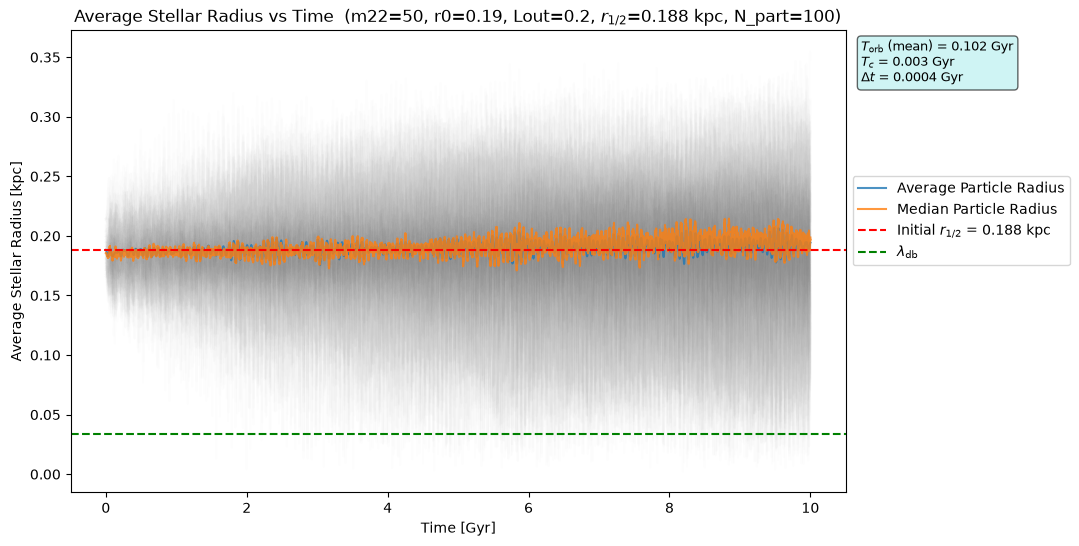

In [35]:
m22 = 50
r0 = 0.19
Lout = 0.2

WORKDIR = "/gpfs/home/jd925/Adding_stellar_masses/Checkpoints/"

m22_str = f"{m22:g}"
r0_str = f"{r0:g}"
lout_str = f"{Lout:g}"

Ckpt_dir = os.path.join(WORKDIR, f"checkpoints_frozen_m22_{m22_str}_r0_{r0_str}_Lout_{lout_str}")

Plot_dir = "/gpfs/home/jd925/Adding_stellar_masses/Plots/Sim_tests/"

os.makedirs(Plot_dir, exist_ok=True)

u = jsp.set_schroedinger_units(m22)

to_Kpc = float(u.to_Kpc)
to_kms = float(u.to_kms)
to_Gyr = float(u.to_Gyr)

print(f"m22={m22}, r0={r0}, Lout={Lout} (checkpoints: {Ckpt_dir})")

# Load final checkpoint
ckpt_path = os.path.join(Ckpt_dir, "checkpoint_final.pkl")
print(f"\nLoading {ckpt_path}")

with open(ckpt_path, "rb") as f:
    state = pickle.load(f)

n_steps = state["no_time_steps"]
n_ramp = state.get("n_ramp_steps", 0)
dt_Gyr = (state["sim_time"] / n_steps) * to_Gyr
#dt_Gyr = (state["sim_t"] / n_steps) * to_Gyr

print(f"Steps: {n_steps}, ramp steps: {n_ramp}, dt = {dt_Gyr:.5f} Gyr")

particles = state["particle_states"]

r_all = np.array([p["r_values"] for p in particles])                              # (N_part, N_steps+1)
v_cart = np.array([[np.asarray(v) for v in p["velocities_cart"]] for p in particles])  # (N_part, N_steps+1, 3)
ke_all = np.array([p["kinetic_energy"]   for p in particles])                       # (N_part, N_steps+1)
pe_all = np.array([p["potential_energy"] for p in particles])                       # (N_part, N_steps+1)
am_all = np.array([p["ang_mom"]          for p in particles])                       # (N_part, N_steps+1[, 3])

N_part, N_t = r_all.shape
print(f"Particles: {N_part}, time points: {N_t}")

# Infer r_half from initial particle radii
r_half_kpc = float(np.mean(r_all[:, 0])) * to_Kpc
r_half_str = f"{r_half_kpc:.2f}"
print(f"Inferred r_half = {r_half_kpc:.4f} kpc")

avg_r = np.mean(r_all, axis=0)         # (N_steps+1,)
median_r = np.median(r_all, axis=0)       # (N_steps+1,)
x = np.arange(N_t) * dt_Gyr       # time axis in Gyr

# Timescale diagnostics from initial conditions (consistent with Running_sims.py)
v0 = np.sqrt(2 * ke_all[:, 0])                        # (N_part,) initial speeds, code units
mean_T_orb = float(np.mean(2 * np.pi * r_all[:, 0] / v0)) * to_Gyr
lambda_db_kpc = 19.15 / (m22 * v0 * to_kms)           # de Broglie wavelength, kpc
T_c = float(np.mean(lambda_db_kpc / (v0 * to_Kpc))) * to_Gyr

print(f"T_orb = {mean_T_orb:.3f} Gyr, T_c = {T_c:.3f} Gyr")


# --- Plot 1: Average stellar radius vs time ---
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(N_part):
    ax.plot(x, r_all[i] * to_Kpc, alpha=0.01, color="gray")

ax.plot(x, avg_r * to_Kpc, label="Average Particle Radius", alpha = 0.8)
ax.plot(x, median_r * to_Kpc, label="Median Particle Radius", alpha = 0.8)

ax.axhline(r_half_kpc, color="r", linestyle="--", label=f"Initial $r_{{1/2}}$ = {r_half_kpc:.3f} kpc", alpha = 1)
ax.axhline(float(np.mean(lambda_db_kpc)), color="g", linestyle="--", label=r"$\lambda_{\rm db}$", alpha = 1)

info = (
    f"$T_{{\\rm orb}}$ (mean) = {mean_T_orb:.3f} Gyr\n"
    f"$T_c$ = {T_c:.3f} Gyr\n"
    f"$\\Delta t$ = {dt_Gyr:.4f} Gyr"
)
ax.text(1.02, 0.98, info, transform=ax.transAxes,
        verticalalignment="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="paleturquoise", alpha=0.6))

ax.set_xlabel("Time [Gyr]")
ax.set_ylabel("Average Stellar Radius [kpc]")
ax.set_title(f"Average Stellar Radius vs Time  (m22={m22}, r0={r0}, Lout={Lout}, $r_{{1/2}}$={r_half_kpc:.3f} kpc, N_part={N_part})")
ax.legend(bbox_to_anchor=(1, 0.7))

plt.show()



In [ ]:
out1 = os.path.join(Plot_dir, f"frozen_lf_m{m22_str}_R0_{r_half_str}_Lout{lout_str}.png")
fig.savefig(out1, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"\nSaved: {out1}")

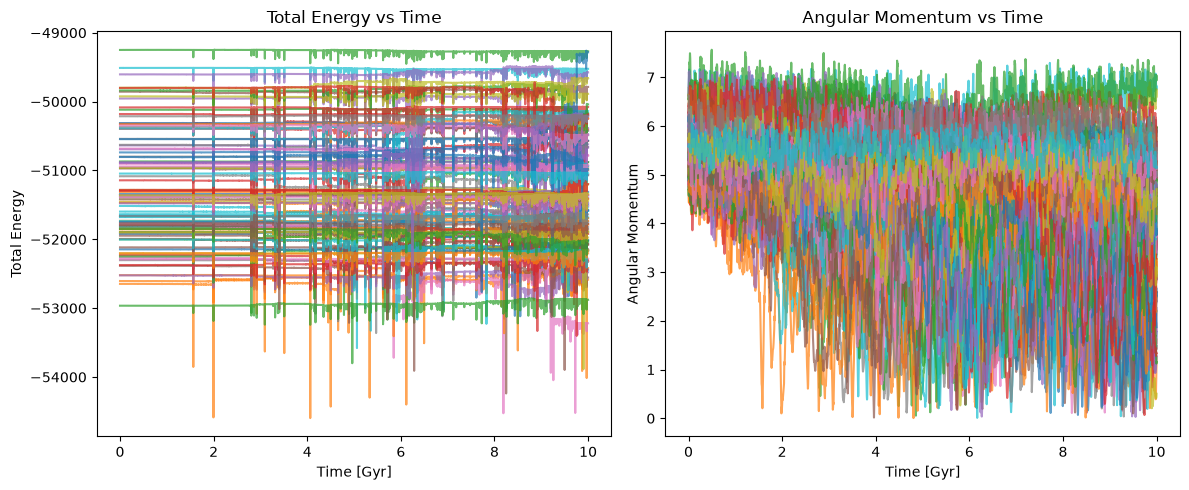

In [36]:
# --- Plot 2: Energy and angular momentum ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i in range(N_part):
    axes[0].plot(x, ke_all[i] + pe_all[i], alpha=0.7, label=f"Particle {i}")
axes[0].set_xlabel("Time [Gyr]")
axes[0].set_ylabel("Total Energy")
axes[0].set_title("Total Energy vs Time")

for i in range(N_part):
    axes[1].plot(x, am_all[i], alpha=0.7)
axes[1].set_xlabel("Time [Gyr]")
axes[1].set_ylabel("Angular Momentum")
axes[1].set_title("Angular Momentum vs Time")

plt.tight_layout()

plt.show()


In [ ]:
out2 = os.path.join(Plot_dir, f"frozen_lf_eng_amom_m{m22_str}_R0_{r_half_str}_Lout{lout_str}.png")
fig.savefig(out2, dpi=300, bbox_inches="tight")
plt.close(fig)
print(f"Saved: {out2}")

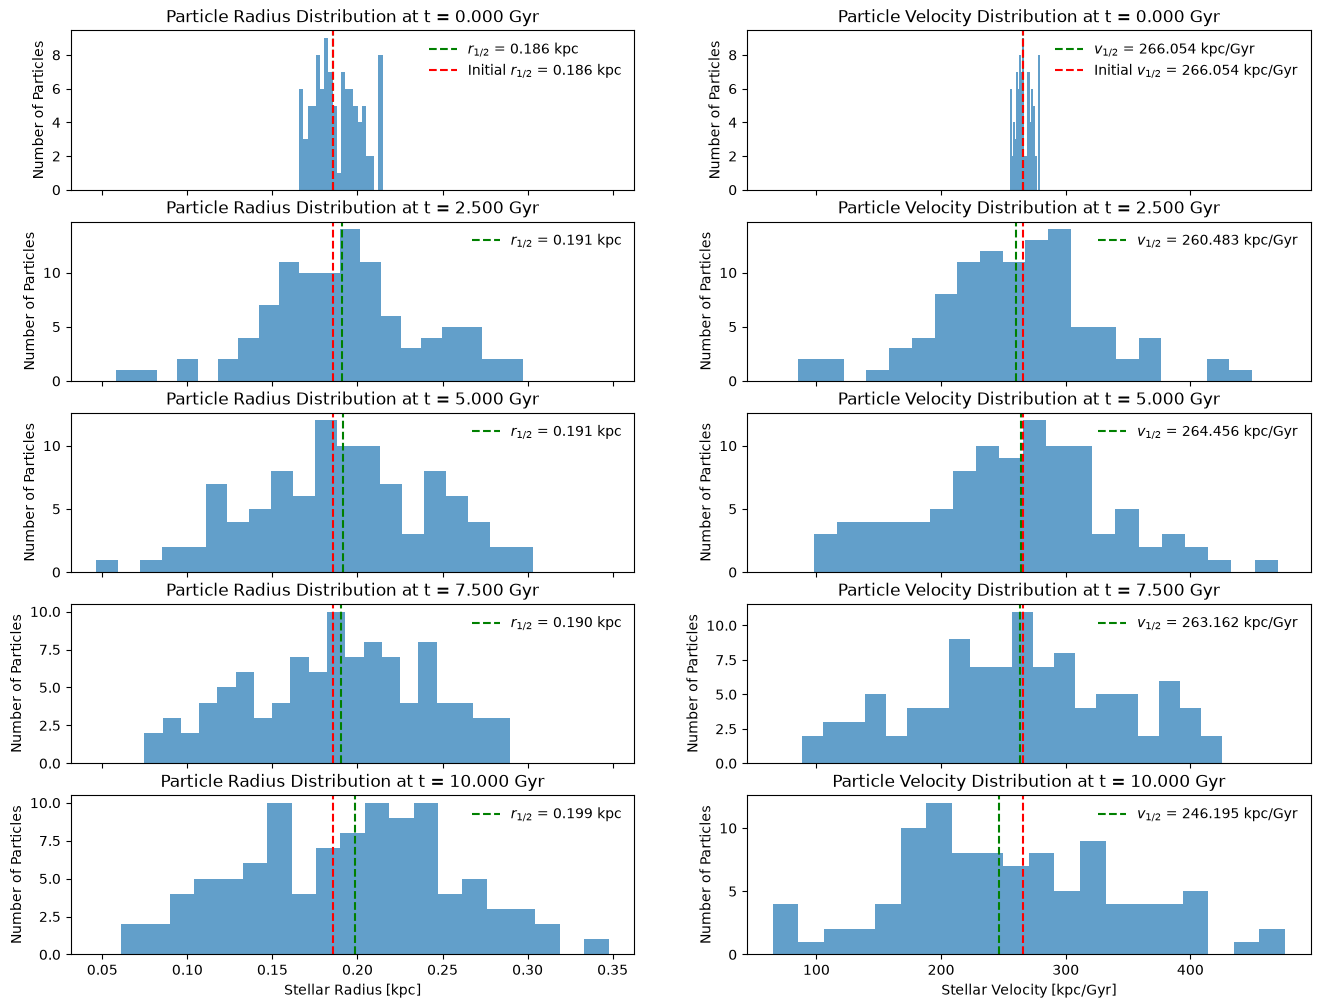

In [37]:
fig, ax = plt.subplots(5, 2, figsize=(16, 12), sharex='col')

v_cart_mag = np.linalg.norm(v_cart, axis=2)  # (N_part, N_steps+1)

timestamps = [0, int(N_t/4), int(N_t/2), int(3*N_t/4), N_t-1]

for i in range(len(timestamps)):

    t = timestamps[i]
    ax[i, 0].hist(r_all[:, t] * to_Kpc, bins=20, alpha=0.7)

    ax[i, 0].set_title(f"Particle Radius Distribution at t = {t*dt_Gyr:.3f} Gyr")

    ax[i, 0].set_ylabel("Number of Particles")

    if i == len(timestamps) - 1:
        ax[i, 0].set_xlabel("Stellar Radius [kpc]")

    ax[i, 0].axvline(np.median(r_all[:, t] * to_Kpc), color="g", linestyle="--", label=f"$r_{{1/2}}$ = {np.median(r_all[:, t] * to_Kpc):.3f} kpc")

    if i == 0:
        ax[i, 0].axvline(np.median(r_all[:, 0] * to_Kpc), color="r", linestyle="--", label=f"Initial $r_{{1/2}}$ = {np.median(r_all[:, 0] * to_Kpc):.3f} kpc")

    else:
        ax[i, 0].axvline(np.median(r_all[:, 0] * to_Kpc), color="r", linestyle="--")

    ax[i, 0].legend(fontsize = 10, frameon = False)


    ax[i, 1].hist(v_cart_mag[:, t] * to_Kpc, bins=20, alpha=0.7)

    ax[i, 1].set_title(f"Particle Velocity Distribution at t = {t*dt_Gyr:.3f} Gyr")

    ax[i, 1].set_ylabel("Number of Particles")

    if i == len(timestamps) - 1:
        ax[i, 1].set_xlabel("Stellar Velocity [kpc/Gyr]")

    ax[i, 1].axvline(np.median(v_cart_mag[:, t] * to_Kpc), color="g", linestyle="--", label=f"$v_{{1/2}}$ = {np.median(v_cart_mag[:, t] * to_Kpc):.3f} kpc/Gyr")


    if i == 0:
        ax[i, 1].axvline(np.median(v_cart_mag[:, 0] * to_Kpc), color="r", linestyle="--", label=f"Initial $v_{{1/2}}$ = {np.median(v_cart_mag[:, 0] * to_Kpc):.3f} kpc/Gyr")

    else:
        ax[i, 1].axvline(np.median(v_cart_mag[:, 0] * to_Kpc), color="r", linestyle="--")

    ax[i, 1].legend(fontsize = 10, frameon = False)

plt.show()
